In [18]:
from pathlib import Path
import random

from IPython.display import display
import numpy as np
import pandas as pd
import torch


def find_project_root(start_path: Path) -> Path:
    for candidate in (start_path.resolve(), *start_path.resolve().parents):
        has_repo_markers = (candidate / ".github").exists() or (candidate / ".git").exists()
        if has_repo_markers and (candidate / "datasets").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate the repository root from notebook working directory: {start_path}"
    )


RANDOM_SEED = 42
PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_TRACK = "EC50"
DATASET_CONFIG = {
    "IC50": {
        "data_dir": PROJECT_ROOT / "datasets" / "postprocessed-CHEMBL379_IC50" / "scaled_dataset",
        "results_root": PROJECT_ROOT / "results" / "large_mlp_optimization" / "IC50",
    },
    "EC50": {
        "data_dir": PROJECT_ROOT / "datasets" / "postprocessed-CHEMBL379_EC50" / "scaled_dataset",
        "results_root": PROJECT_ROOT / "results" / "large_mlp_optimization" / "EC50",
    },
}
if DATASET_TRACK not in DATASET_CONFIG:
    available_tracks = ", ".join(sorted(DATASET_CONFIG))
    raise ValueError(
        f"Unsupported dataset track '{DATASET_TRACK}'. Expected one of: {available_tracks}"
    )

TRACK_CONFIG = DATASET_CONFIG[DATASET_TRACK]
DATA_DIR = TRACK_CONFIG["data_dir"]
RESULTS_ROOT = TRACK_CONFIG["results_root"]
TARGET_COLUMN = "activity"
METADATA_COLUMNS = [
    "representative_molecule_chembl_id",
    "smiles",
    "canonical_smiles",
    "activity",
    "threshold_nm",
    "source_record_count",
    "source_molecule_chembl_ids",
    "source_relations",
    "source_values_nm",
    "label_sources",
    "target_chembl_id",
]

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Expected scaled dataset directory was not found: {DATA_DIR}")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset track: {DATASET_TRACK}")
print(f"Scaled dataset directory: {DATA_DIR}")
print(f"Using device: {device}")

Project root: C:\Users\CaVi962\vscodeprojects\Magestic-NN
Dataset track: EC50
Scaled dataset directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\datasets\postprocessed-CHEMBL379_EC50\scaled_dataset
Using device: cpu


In [19]:
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


def create_next_experiment_run_dir(results_root: Path) -> Path:
    experiment_indices: list[int] = []

    for candidate in results_root.iterdir():
        if not candidate.is_dir() or not candidate.name.startswith("experiment_"):
            continue

        suffix = candidate.name.removeprefix("experiment_")
        if suffix.isdigit():
            experiment_indices.append(int(suffix))

    next_index = max(experiment_indices, default=0) + 1
    return results_root / f"experiment_{next_index:03d}"


existing_run_dir = globals().get("RUN_DIR")
reuse_existing_run_dir = False

if isinstance(existing_run_dir, Path):
    try:
        reuse_existing_run_dir = (
            existing_run_dir.parent == RESULTS_ROOT
            and existing_run_dir.name.startswith("experiment_")
        )
    except OSError:
        reuse_existing_run_dir = False

if reuse_existing_run_dir:
    RUN_DIR = existing_run_dir
else:
    RUN_DIR = create_next_experiment_run_dir(RESULTS_ROOT)

HISTORY_DIR = RUN_DIR / "history"
PLOTS_DIR = RUN_DIR / "plots"

for output_dir in (RUN_DIR, HISTORY_DIR, PLOTS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"Large-model optimization results root for {DATASET_TRACK}: {RESULTS_ROOT}")
print(f"Current run directory: {RUN_DIR}")
if reuse_existing_run_dir:
    print("Reusing existing run directory for this kernel session.")
else:
    print("Allocated a new run directory for this kernel session.")

Large-model optimization results root for EC50: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\large_mlp_optimization\EC50
Current run directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\large_mlp_optimization\EC50\experiment_001
Allocated a new run directory for this kernel session.


In [20]:
train_df = pd.read_csv(DATA_DIR / "train_dataset.csv")
validation_df = pd.read_csv(DATA_DIR / "validation_dataset.csv")
test_df = pd.read_csv(DATA_DIR / "test_dataset.csv")

print("Loaded splits:")
print(f"train: {train_df.shape}")
print(f"validation: {validation_df.shape}")
print(f"test: {test_df.shape}")

Loaded splits:
train: (6885, 85)
validation: (861, 85)
test: (861, 85)


In [21]:
descriptor_columns = [
    column_name
    for column_name in train_df.columns
    if column_name not in METADATA_COLUMNS
]
validation_descriptor_columns = [
    column_name
    for column_name in validation_df.columns
    if column_name not in METADATA_COLUMNS
]
test_descriptor_columns = [
    column_name
    for column_name in test_df.columns
    if column_name not in METADATA_COLUMNS
]

assert TARGET_COLUMN in train_df.columns
assert TARGET_COLUMN in validation_df.columns
assert TARGET_COLUMN in test_df.columns
assert descriptor_columns == validation_descriptor_columns == test_descriptor_columns, (
    "Train, validation, and test splits do not share the same descriptor columns."
)
assert not train_df[descriptor_columns].isnull().any().any()
assert not validation_df[descriptor_columns].isnull().any().any()
assert not test_df[descriptor_columns].isnull().any().any()
assert set(train_df[TARGET_COLUMN].unique()) <= {0, 1}
assert set(validation_df[TARGET_COLUMN].unique()) <= {0, 1}
assert set(test_df[TARGET_COLUMN].unique()) <= {0, 1}

sanity_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(validation_df), len(test_df)],
        "active": [
            int(train_df[TARGET_COLUMN].sum()),
            int(validation_df[TARGET_COLUMN].sum()),
            int(test_df[TARGET_COLUMN].sum()),
        ],
        "inactive": [
            int((train_df[TARGET_COLUMN] == 0).sum()),
            int((validation_df[TARGET_COLUMN] == 0).sum()),
            int((test_df[TARGET_COLUMN] == 0).sum()),
        ],
    }
)

print(f"Descriptor column count: {len(descriptor_columns)}")
display(sanity_summary)

Descriptor column count: 74


,split,rows,active,inactive
0,train,6885,3150,3735
1,validation,861,394,467
2,test,861,394,467


In [22]:
train_metadata = train_df[METADATA_COLUMNS].copy()
validation_metadata = validation_df[METADATA_COLUMNS].copy()
test_metadata = test_df[METADATA_COLUMNS].copy()

X_train_df = train_df[descriptor_columns].copy()
X_validation_df = validation_df[descriptor_columns].copy()
X_test_df = test_df[descriptor_columns].copy()

y_train_series = train_df[TARGET_COLUMN].astype(np.float32)
y_validation_series = validation_df[TARGET_COLUMN].astype(np.float32)
y_test_series = test_df[TARGET_COLUMN].astype(np.float32)

X_train = torch.tensor(X_train_df.to_numpy(dtype=np.float32), dtype=torch.float32)
X_validation = torch.tensor(
    X_validation_df.to_numpy(dtype=np.float32),
    dtype=torch.float32,
 )
X_test = torch.tensor(X_test_df.to_numpy(dtype=np.float32), dtype=torch.float32)

y_train = torch.tensor(
    y_train_series.to_numpy(dtype=np.float32),
    dtype=torch.float32,
).unsqueeze(1)
y_validation = torch.tensor(
    y_validation_series.to_numpy(dtype=np.float32),
    dtype=torch.float32,
).unsqueeze(1)
y_test = torch.tensor(
    y_test_series.to_numpy(dtype=np.float32),
    dtype=torch.float32,
).unsqueeze(1)

print(f"X_train shape: {tuple(X_train.shape)}, y_train shape: {tuple(y_train.shape)}")
print(
    f"X_validation shape: {tuple(X_validation.shape)}, "
    f"y_validation shape: {tuple(y_validation.shape)}"
 )
print(f"X_test shape: {tuple(X_test.shape)}, y_test shape: {tuple(y_test.shape)}")

X_train shape: (6885, 74), y_train shape: (6885, 1)
X_validation shape: (861, 74), y_validation shape: (861, 1)
X_test shape: (861, 74), y_test shape: (861, 1)


In [23]:
from torch.utils.data import DataLoader, TensorDataset

TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

sample_features, sample_targets = next(iter(train_loader))

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Test batches: {len(test_loader)}")
print(
    f"Sample training batch shapes: X={tuple(sample_features.shape)}, "
    f"y={tuple(sample_targets.shape)}"
 )

Train batches: 216
Validation batches: 14
Test batches: 14
Sample training batch shapes: X=(32, 74), y=(32, 1)


In [24]:
import torch.nn as nn

MODEL_NAME = "optimized_large_mlp"
MODEL_WIDTH = 256
RESIDUAL_BLOCKS = 2
HEAD_WIDTHS = [128, 64]
INPUT_DROPOUT_RATE = 0.10
HIDDEN_DROPOUT_RATE = 0.35


class ResidualMLPBlock(nn.Module):
    def __init__(self, dim: int, dropout: float) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
        )
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        outputs = self.block(inputs)
        outputs = outputs + inputs
        outputs = self.activation(outputs)
        return self.dropout(outputs)


class OptimizedLargeMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        width: int = MODEL_WIDTH,
        input_dropout: float = INPUT_DROPOUT_RATE,
        hidden_dropout: float = HIDDEN_DROPOUT_RATE,
    ) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, width),
            nn.LayerNorm(width),
            nn.GELU(),
            nn.Dropout(input_dropout),
        )
        self.residual_backbone = nn.Sequential(
            *[ResidualMLPBlock(width, hidden_dropout) for _ in range(RESIDUAL_BLOCKS)]
        )
        self.head = nn.Sequential(
            nn.Linear(width, HEAD_WIDTHS[0]),
            nn.LayerNorm(HEAD_WIDTHS[0]),
            nn.GELU(),
            nn.Dropout(hidden_dropout),
            nn.Linear(HEAD_WIDTHS[0], HEAD_WIDTHS[1]),
            nn.LayerNorm(HEAD_WIDTHS[1]),
            nn.GELU(),
            nn.Dropout(hidden_dropout),
            nn.Linear(HEAD_WIDTHS[1], 1),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        outputs = self.input_projection(inputs)
        outputs = self.residual_backbone(outputs)
        return self.head(outputs)


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


INPUT_DIM = X_train.shape[1]
architecture_summary = pd.DataFrame(
    [
        {
            "model": MODEL_NAME,
            "input_dim": INPUT_DIM,
            "model_width": MODEL_WIDTH,
            "residual_blocks": RESIDUAL_BLOCKS,
            "head_widths": HEAD_WIDTHS,
            "input_dropout": INPUT_DROPOUT_RATE,
            "hidden_dropout": HIDDEN_DROPOUT_RATE,
            "trainable_parameters": count_trainable_parameters(OptimizedLargeMLP(INPUT_DIM)),
        }
    ]
)

optimized_large_model = OptimizedLargeMLP(INPUT_DIM).to(device)

display(architecture_summary)
print(optimized_large_model)

,model,input_dim,model_width,residual_blocks,head_widths,input_dropout,hidden_dropout,trainable_parameters
0,optimized_large_mlp,74,256,2,"[128, 64]",0.1,0.35,326529


OptimizedLargeMLP(
  (input_projection): Sequential(
    (0): Linear(in_features=74, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
  )
  (residual_backbone): Sequential(
    (0): ResidualMLPBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.35, inplace=False)
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
      (activation): GELU(approximate='none')
      (dropout): Dropout(p=0.35, inplace=False)
    )
    (1): ResidualMLPBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): GE

In [ ]:
from collections.abc import Callable
from copy import deepcopy

import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tqdm import tqdm

MAX_EPOCHS = 100
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 5e-4
CLASS_LABELS = ("Inactive (0)", "Active (1)")
DEFAULT_DECISION_THRESHOLD = 0.5


def reset_random_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def collect_predictions(model: nn.Module, data_loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    collected_targets = []
    collected_logits = []

    with torch.no_grad():
        for batch_features, batch_targets in data_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            batch_logits = model(batch_features)

            collected_targets.append(batch_targets.detach().cpu().numpy())
            collected_logits.append(batch_logits.detach().cpu().numpy())

    targets = np.vstack(collected_targets).reshape(-1)
    logits = np.vstack(collected_logits).reshape(-1)
    return targets, logits


def build_prediction_outputs(
    targets: np.ndarray,
    logits: np.ndarray,
    threshold: float = DEFAULT_DECISION_THRESHOLD,
) -> dict[str, np.ndarray]:
    probabilities = 1.0 / (1.0 + np.exp(-logits))
    predictions = (probabilities >= threshold).astype(np.int64)

    return {
        "targets": targets.astype(np.int64),
        "logits": logits,
        "probabilities": probabilities,
        "predictions": predictions,
    }


def compute_binary_classification_metrics(
    targets: np.ndarray,
    logits: np.ndarray,
    threshold: float = DEFAULT_DECISION_THRESHOLD,
) -> dict[str, float]:
    prediction_outputs = build_prediction_outputs(targets, logits, threshold=threshold)
    probabilities = prediction_outputs["probabilities"]
    predictions = prediction_outputs["predictions"]

    return {
        "accuracy": float(accuracy_score(targets, predictions)),
        "precision": float(precision_score(targets, predictions, zero_division=0)),
        "recall": float(recall_score(targets, predictions, zero_division=0)),
        "f1": float(f1_score(targets, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(targets, probabilities)),
    }


def select_optimal_f1_threshold(
    targets: np.ndarray,
    logits: np.ndarray,
    default_threshold: float = DEFAULT_DECISION_THRESHOLD,
) -> float:
    probabilities = 1.0 / (1.0 + np.exp(-logits))
    candidate_thresholds = np.unique(
        np.concatenate((np.array([0.0, default_threshold, 1.0]), probabilities))
    )

    best_threshold = float(default_threshold)
    best_f1 = -1.0

    for threshold in candidate_thresholds:
        predictions = (probabilities >= threshold).astype(np.int64)
        threshold_f1 = float(f1_score(targets, predictions, zero_division=0))
        if threshold_f1 > best_f1 or (
            np.isclose(threshold_f1, best_f1)
            and abs(float(threshold) - default_threshold)
            < abs(best_threshold - default_threshold)
        ):
            best_f1 = threshold_f1
            best_threshold = float(threshold)

    return best_threshold


def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    threshold: float = DEFAULT_DECISION_THRESHOLD,
) -> dict[str, float]:
    model.eval()
    running_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for batch_features, batch_targets in data_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            batch_logits = model(batch_features)
            batch_loss = loss_function(batch_logits, batch_targets)

            batch_size = batch_features.size(0)
            running_loss += batch_loss.item() * batch_size
            total_examples += batch_size

    targets, logits = collect_predictions(model, data_loader)
    metrics = compute_binary_classification_metrics(targets, logits, threshold=threshold)
    metrics["loss"] = running_loss / total_examples
    return metrics


def plot_training_history_axes(
    axes: np.ndarray,
    history_frame: pd.DataFrame,
    experiment_name: str,
) -> None:
    loss_axis, metric_axis = axes

    loss_axis.clear()
    metric_axis.clear()

    if not history_frame.empty:
        loss_axis.plot(
            history_frame["epoch"],
            history_frame["train_loss"],
            marker="o",
            label="Train loss",
        )
        loss_axis.plot(
            history_frame["epoch"],
            history_frame["validation_loss"],
            marker="o",
            label="Validation loss",
        )
        best_epoch = int(history_frame.loc[history_frame["validation_loss"].idxmin(), "epoch"])
        loss_axis.axvline(
            best_epoch,
            color="tab:gray",
            linestyle="--",
            alpha=0.5,
            label="Best validation loss",
        )

        metric_axis.plot(
            history_frame["epoch"],
            history_frame["validation_f1"],
            marker="o",
            label=f"Validation F1 (threshold={DEFAULT_DECISION_THRESHOLD:.2f})",
        )
        metric_axis.plot(
            history_frame["epoch"],
            history_frame["validation_roc_auc"],
            marker="o",
            label="Validation ROC-AUC",
        )

    loss_axis.set_title(f"{experiment_name}: train vs validation loss")
    loss_axis.set_xlabel("Epoch")
    loss_axis.set_ylabel("BCE loss")
    loss_axis.grid(True, alpha=0.3)
    loss_axis.legend()

    metric_axis.set_title(f"{experiment_name}: validation metrics")
    metric_axis.set_xlabel("Epoch")
    metric_axis.set_ylabel("Score")
    metric_axis.set_ylim(0.0, 1.0)
    metric_axis.grid(True, alpha=0.3)
    metric_axis.legend()


def create_training_history_figure(
    history_frame: pd.DataFrame,
    experiment_name: str,
) -> tuple[plt.Figure, np.ndarray]:
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_training_history_axes(axes, history_frame, experiment_name)
    figure.tight_layout()
    return figure, axes


def build_large_model() -> nn.Module:
    return OptimizedLargeMLP(
        INPUT_DIM,
        width=MODEL_WIDTH,
        input_dropout=INPUT_DROPOUT_RATE,
        hidden_dropout=HIDDEN_DROPOUT_RATE,
    ).to(device)


def train_model(
    model: nn.Module,
    train_data_loader: DataLoader,
    validation_data_loader: DataLoader,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    max_epochs: int = MAX_EPOCHS,
    experiment_name: str = MODEL_NAME,
    show_live_dashboard: bool = True,
) -> tuple[nn.Module, pd.DataFrame, dict[str, float], int]:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    loss_function = nn.BCEWithLogitsLoss()

    best_model_state = deepcopy(model.state_dict())
    best_validation_metrics: dict[str, float] | None = None
    best_validation_loss = float("inf")
    history_rows: list[dict[str, float | int]] = []

    dashboard_figure = None
    dashboard_axes = None
    dashboard_handle = None
    if show_live_dashboard:
        dashboard_figure, dashboard_axes = create_training_history_figure(
            pd.DataFrame(),
            experiment_name,
        )
        dashboard_figure.suptitle(f"Training monitor: {experiment_name}")
        dashboard_handle = display(dashboard_figure, display_id=True)
        plt.close(dashboard_figure)

    progress_bar = tqdm(
        range(1, max_epochs + 1),
        desc=f"{experiment_name} epochs",
        leave=True,
    )

    for epoch in progress_bar:
        model.train()
        running_training_loss = 0.0
        total_training_examples = 0

        for batch_features, batch_targets in train_data_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()
            batch_logits = model(batch_features)
            batch_loss = loss_function(batch_logits, batch_targets)
            batch_loss.backward()
            optimizer.step()

            batch_size = batch_features.size(0)
            running_training_loss += batch_loss.item() * batch_size
            total_training_examples += batch_size

        train_loss = running_training_loss / total_training_examples
        validation_metrics = evaluate_model(
            model,
            validation_data_loader,
            loss_function,
        )

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "validation_loss": validation_metrics["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
                "validation_precision": validation_metrics["precision"],
                "validation_recall": validation_metrics["recall"],
                "validation_f1": validation_metrics["f1"],
                "validation_roc_auc": validation_metrics["roc_auc"],
            }
        )

        history_frame = pd.DataFrame(history_rows)
        progress_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            val_loss=f"{validation_metrics['loss']:.4f}",
            val_f1=f"{validation_metrics['f1']:.4f}",
        )

        if dashboard_handle is not None and dashboard_figure is not None and dashboard_axes is not None:
            plot_training_history_axes(dashboard_axes, history_frame, experiment_name)
            dashboard_figure.suptitle(f"Training monitor: {experiment_name}")
            dashboard_figure.tight_layout()
            dashboard_handle.update(dashboard_figure)

        if validation_metrics["loss"] < best_validation_loss:
            best_validation_loss = validation_metrics["loss"]
            best_validation_metrics = validation_metrics.copy()
            best_model_state = deepcopy(model.state_dict())

    progress_bar.close()

    model.load_state_dict(best_model_state)
    history_frame = pd.DataFrame(history_rows)
    if best_validation_metrics is None:
        raise RuntimeError("Training finished without recording validation metrics.")

    best_epoch = int(history_frame.loc[history_frame["validation_loss"].idxmin(), "epoch"])
    return model, history_frame, best_validation_metrics, best_epoch


def run_experiment(
    experiment_name: str = MODEL_NAME,
    model_builder: Callable[[], nn.Module] | None = None,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    max_epochs: int = MAX_EPOCHS,
    show_live_dashboard: bool = True,
) -> dict[str, object]:
    reset_random_seed(RANDOM_SEED)
    if model_builder is None:
        model_builder = build_large_model
    model = model_builder()
    trained_model, history_frame, best_validation_metrics, best_epoch = train_model(
        model,
        train_loader,
        validation_loader,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        max_epochs=max_epochs,
        experiment_name=experiment_name,
        show_live_dashboard=show_live_dashboard,
    )
    loss_function = nn.BCEWithLogitsLoss()
    validation_targets, validation_logits = collect_predictions(trained_model, validation_loader)
    decision_threshold = select_optimal_f1_threshold(validation_targets, validation_logits)
    validation_metrics = evaluate_model(
        trained_model,
        validation_loader,
        loss_function,
        threshold=decision_threshold,
    )
    test_metrics = evaluate_model(
        trained_model,
        test_loader,
        loss_function,
        threshold=decision_threshold,
    )
    test_targets, test_logits = collect_predictions(trained_model, test_loader)
    test_outputs = build_prediction_outputs(
        test_targets,
        test_logits,
        threshold=decision_threshold,
    )
    test_confusion_matrix = confusion_matrix(
        test_outputs["targets"],
        test_outputs["predictions"],
        labels=[0, 1],
    )

    summary = pd.DataFrame(
        [
            {
                "experiment": experiment_name,
                "architecture_variant": MODEL_NAME,
                "hidden_layers": [MODEL_WIDTH, MODEL_WIDTH, *HEAD_WIDTHS],
                "model_width": MODEL_WIDTH,
                "residual_blocks": RESIDUAL_BLOCKS,
                "input_dropout": INPUT_DROPOUT_RATE,
                "hidden_dropout": HIDDEN_DROPOUT_RATE,
                "decision_threshold": decision_threshold,
                "epochs_trained": int(history_frame["epoch"].iloc[-1]),
                "best_epoch": best_epoch,
                "validation_loss": validation_metrics["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
                "validation_precision": validation_metrics["precision"],
                "validation_recall": validation_metrics["recall"],
                "validation_f1": validation_metrics["f1"],
                "validation_roc_auc": validation_metrics["roc_auc"],
                "test_loss": test_metrics["loss"],
                "test_accuracy": test_metrics["accuracy"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
                "test_roc_auc": test_metrics["roc_auc"],
            }
        ]
    )

    return {
        "model": trained_model,
        "history": history_frame,
        "summary": summary,
        "decision_threshold": decision_threshold,
        "test_targets": test_outputs["targets"],
        "test_probabilities": test_outputs["probabilities"],
        "test_predictions": test_outputs["predictions"],
        "test_confusion_matrix": test_confusion_matrix,
    }


def build_confusion_matrix_summary(experiments: list[dict[str, object]]) -> pd.DataFrame:
    summary_rows = []

    for experiment in experiments:
        tn, fp, fn, tp = experiment["test_confusion_matrix"].ravel()
        experiment_name = str(experiment["summary"].iloc[0]["experiment"])
        summary_rows.append(
            {
                "experiment": experiment_name,
                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp),
            }
        )

    return pd.DataFrame(summary_rows)


def plot_confusion_matrices(
    experiments: list[dict[str, object]],
    class_labels: tuple[str, str] = CLASS_LABELS,
) -> tuple[plt.Figure, np.ndarray]:
    if not experiments:
        raise RuntimeError(
            "No experiment results are available. Run the large-model experiment cell first."
        )

    figure, axes = plt.subplots(1, len(experiments), figsize=(5 * len(experiments), 4.5))
    if len(experiments) == 1:
        axes = np.array([axes], dtype=object)

    for axis, experiment in zip(axes, experiments):
        experiment_name = str(experiment["summary"].iloc[0]["experiment"])
        matrix_display = ConfusionMatrixDisplay(
            confusion_matrix=experiment["test_confusion_matrix"],
            display_labels=list(class_labels),
        )
        matrix_display.plot(ax=axis, colorbar=False, values_format="d")
        axis.set_title(f"{experiment_name} test set")
        axis.set_xlabel("Predicted label")
        axis.set_ylabel("True label")

    figure.suptitle("Confusion matrices: rows = true labels, columns = predicted labels")
    figure.tight_layout()
    return figure, axes


print(
    "Large-model optimization utilities ready. The notebook reuses the main data pipeline, trains one optimized large model with loss-based checkpoint restoration, and selects a validation-tuned decision threshold for the final classification metrics. "
    f"Defaults: epochs={MAX_EPOCHS}, lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}, base_threshold={DEFAULT_DECISION_THRESHOLD}" 
)

Large-model optimization utilities ready. The notebook reuses the main data pipeline and trains one optimized large model with loss-based checkpoint restoration. Defaults: epochs=100, lr=0.0005, weight_decay=0.0005


C:\Users\CaVi962\AppData\Local\Temp\ipykernel_31204\1008773624.py:153: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  loss_axis.legend()
C:\Users\CaVi962\AppData\Local\Temp\ipykernel_31204\1008773624.py:160: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  metric_axis.legend()


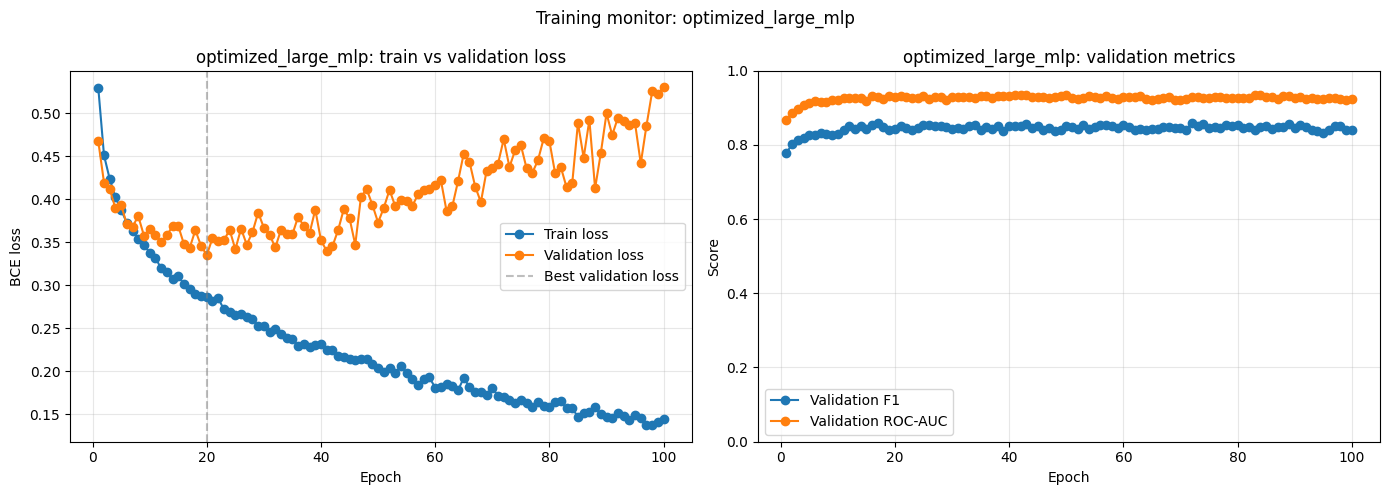

optimized_large_mlp epochs: 100%|██████████| 100/100 [03:23<00:00,  2.04s/it, train_loss=0.1443, val_f1=0.8408, val_loss=0.5300]


,experiment,architecture_variant,hidden_layers,model_width,residual_blocks,input_dropout,hidden_dropout,epochs_trained,best_epoch,validation_loss,...,validation_precision,validation_recall,validation_f1,validation_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,optimized_large_mlp,optimized_large_mlp,"[256, 256, 128, 64]",256,2,0.1,0.35,100,20,0.335186,...,0.861702,0.822335,0.841558,0.930146,0.331527,0.87108,0.885559,0.824873,0.854139,0.933339


,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc
95,96,0.145327,0.441677,0.858304,0.863636,0.819797,0.841146,0.927407
96,97,0.138016,0.485690,0.860627,0.837438,0.862944,0.850000,0.927385
97,98,0.137918,0.525404,0.862950,0.845000,0.857868,0.851385,0.922374
98,99,0.140898,0.522793,0.849013,0.814286,0.868020,0.840295,0.920611
99,100,0.144340,0.530036,0.851336,0.824390,0.857868,0.840796,0.922157


In [29]:
large_model_experiment = run_experiment()

display(large_model_experiment["summary"])
display(large_model_experiment["history"].tail())

Confusion matrix on the test set. Rows = true labels, columns = predicted labels. Class order: Inactive (0), Active (1).


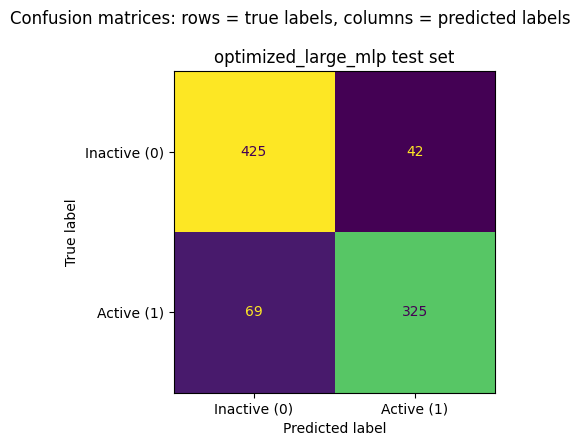

,experiment,tn,fp,fn,tp
0,optimized_large_mlp,425,42,69,325


In [27]:
experiment_names = ["large_model_experiment"]

available_experiments = [
    globals()[name]
    for name in experiment_names
    if name in globals()
]

if not available_experiments:
    raise RuntimeError(
        "Run the large-model experiment cell before plotting confusion matrices."
    )

print(
    "Confusion matrix on the test set. "
    "Rows = true labels, columns = predicted labels. "
    "Class order: Inactive (0), Active (1)."
)

confusion_matrix_figure, _ = plot_confusion_matrices(available_experiments)
confusion_matrix_summary = build_confusion_matrix_summary(available_experiments)

display(confusion_matrix_figure)
display(confusion_matrix_summary)
plt.close(confusion_matrix_figure)

In [30]:
from datetime import datetime
import json

experiment_names = ["large_model_experiment"]

available_experiments = [
    globals()[name]
    for name in experiment_names
    if name in globals()
]

if not available_experiments:
    raise RuntimeError("Run the large-model experiment cell before exporting results.")

for output_dir in (RUN_DIR, HISTORY_DIR, PLOTS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

results_summary = pd.concat(
    [experiment["summary"] for experiment in available_experiments],
    ignore_index=True,
)
confusion_matrix_summary = build_confusion_matrix_summary(available_experiments)

run_timestamp = datetime.now().isoformat(timespec="seconds")

summary_path = RUN_DIR / "summary.csv"
json_path = RUN_DIR / "summary.json"
confusion_summary_path = RUN_DIR / "test_confusion_summary.csv"

results_summary.to_csv(summary_path, index=False)
confusion_matrix_summary.to_csv(confusion_summary_path, index=False)

history_files = []
training_curve_files = []

for experiment in available_experiments:
    experiment_name = str(experiment["summary"].iloc[0]["experiment"])
    history_path = HISTORY_DIR / f"{experiment_name}_history.csv"
    training_curve_path = PLOTS_DIR / f"{experiment_name}_training_curves.png"

    experiment["history"].to_csv(history_path, index=False)

    history_figure, _ = create_training_history_figure(
        experiment["history"],
        experiment_name,
    )
    history_figure.savefig(
        training_curve_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.close(history_figure)

    history_files.append(history_path.relative_to(PROJECT_ROOT).as_posix())
    training_curve_files.append(
        training_curve_path.relative_to(PROJECT_ROOT).as_posix()
    )

confusion_matrix_path = PLOTS_DIR / "test_confusion_matrices.png"
confusion_matrix_figure, _ = plot_confusion_matrices(available_experiments)
confusion_matrix_figure.savefig(
    confusion_matrix_path,
    dpi=200,
    bbox_inches="tight",
)
plt.close(confusion_matrix_figure)

payload = {
    "run_directory": RUN_DIR.relative_to(PROJECT_ROOT).as_posix(),
    "run_timestamp": run_timestamp,
    "device": str(device),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "summary_file": summary_path.relative_to(PROJECT_ROOT).as_posix(),
    "confusion_summary_file": confusion_summary_path.relative_to(PROJECT_ROOT).as_posix(),
    "history_files": history_files,
    "training_curve_files": training_curve_files,
    "confusion_matrix_file": confusion_matrix_path.relative_to(PROJECT_ROOT).as_posix(),
    "results": results_summary.to_dict(orient="records"),
}

with json_path.open("w", encoding="utf-8") as file:
    json.dump(payload, file, indent=2)

display(results_summary)
display(confusion_matrix_summary)
print(f"Saved run directory: {RUN_DIR}")
print(f"Saved summary CSV: {summary_path}")
print(f"Saved summary JSON: {json_path}")
print(f"Saved confusion summary CSV: {confusion_summary_path}")
print(f"Saved confusion matrix figure: {confusion_matrix_path}")

,experiment,architecture_variant,hidden_layers,model_width,residual_blocks,input_dropout,hidden_dropout,epochs_trained,best_epoch,validation_loss,...,validation_precision,validation_recall,validation_f1,validation_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,optimized_large_mlp,optimized_large_mlp,"[256, 256, 128, 64]",256,2,0.1,0.35,100,20,0.335186,...,0.861702,0.822335,0.841558,0.930146,0.331527,0.87108,0.885559,0.824873,0.854139,0.933339


,experiment,tn,fp,fn,tp
0,optimized_large_mlp,425,42,69,325


Saved run directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\large_mlp_optimization\EC50\experiment_001
Saved summary CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\large_mlp_optimization\EC50\experiment_001\summary.csv
Saved summary JSON: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\large_mlp_optimization\EC50\experiment_001\summary.json
Saved confusion summary CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\large_mlp_optimization\EC50\experiment_001\test_confusion_summary.csv
Saved confusion matrix figure: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\large_mlp_optimization\EC50\experiment_001\plots\test_confusion_matrices.png
